# Week 3 - Linear Regression, Part 3

# Analysis



This is a part As part of the Capstone Project. This week the following models will be used:

- Forward Selection
- Backward Selection
- Principal Component Regression

# Datasets

## All Datasets

In [1]:
# Shared imports for classification modeling (used by all datasets below)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              mean_squared_error, mean_absolute_error, r2_score,
                              explained_variance_score)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
pd.set_option('display.max_columns', 100)

In [3]:
# Shared helpers for feature-selection / dimensionality-reduction regression modeling
# (used by all datasets below)
def compute_vif(X):
    """Variance Inflation Factor for every column of X (VIF_i = 1 / (1 - R^2) from
    regressing feature i on all the other columns of X). VIF > 5 is often treated as
    a caution, VIF > 10 as a serious multicollinearity problem."""
    vifs = {}
    for col in X.columns:
        y_i = X[col].values
        X_rest = X.drop(columns=[col]).values
        r2 = LinearRegression().fit(X_rest, y_i).score(X_rest, y_i)
        vifs[col] = np.inf if r2 >= 1 - 1e-8 else 1.0 / (1.0 - r2)
    return pd.Series(vifs, name="VIF").sort_values(ascending=False)

def fit_and_report(model, X_train, y_train, X_test, y_test, label):
    """Fit a linear model and report R^2 / RMSE / MAE on the held-out test set."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{label:38s} R^2={r2:8.4f}   RMSE={rmse:14,.2f}   MAE={mae:14,.2f}")
    return model, {"model": label, "R2": r2, "RMSE": rmse, "MAE": mae}

def to_protocol_category(protocol_col):
    """Map the numeric CICFlowMeter Protocol code to a readable categorical label."""
    mapping = {6: "TCP", 17: "UDP"}
    return protocol_col.map(lambda p: mapping.get(int(p), "OTHER"))

def to_port_tier(port_col):
    """Bin a destination-port column into the standard IANA categorical tiers - used as
    a categorical feature when a dataset has no explicit Protocol column."""
    def tier(p):
        p = int(p)
        if p < 1024:
            return "well_known"
        elif p < 49152:
            return "registered"
        else:
            return "dynamic"
    return port_col.apply(tier)


## Dataset 1: Malware

### Setup

In [4]:
# Load the dataset
files = [
    "malware_benign_1.csv",
    "malware_benign_2.csv",
    "malware_benign_3.csv",
    "malware_benign_4.csv",
    "malware_benign_5.csv",
    "malware_benign_6.csv",
    "malware_benign_7.csv",
    "malware_benign_8.csv",
    "malware_benign_9.csv",
    "malware_benign_10.csv",
    "malware_benign_11.csv",
    "malware_benign_12.csv",
    "malware_benign_13.csv",
    "malware_benign_14.csv",
    "malware_benign_15.csv",
    "ransomware_wannalocker_1.csv",
    "ransomware_wannalocker_2.csv",
    "ransomware_wannalocker_3.csv",
    "ransomware_wannalocker_4.csv",
    "ransomware_wannalocker_5.csv",
    "ransomware_wannalocker_6.csv",
    "ransomware_wannalocker_7.csv",
    "ransomware_wannalocker_8.csv",
    "ransomware_wannalocker_9.csv"
]

dfs = []
for f in files:
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()  # source CSVs have inconsistent leading spaces in headers
    dfs.append(df)

ransomware_df = pd.concat(dfs, ignore_index=True)
print(ransomware_df.shape)

(37839, 85)


In [5]:
# Print the dataset
ransomware_df.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,0,1,0,0,0,0,1.0,403.642857,179.333333,571.875000,200,0,0,0,0,0,0,6,1076,8,4575,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,349,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,65902.578797,5730.659026,349.000000,0.000000,349.0,349.0,349.0,349.0,0.000000,349.0,349.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,5730.659026,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1594,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,172.217.12.174-10.42.0.211-443-34259-6,10.42.0.211,34259,172.217.12.174,443,6,16/06/2017 03:55:52,119,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,193277.310924,16806.722689,119.000000,0.000000,119.0,119.0,119.0,119.0,0.000000,119.0,119.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,16806.722689,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1486,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,172.217.10.74-10.42.0.211-443-55509-6,10.42.0.211,55509,172.217.10.74,443,6,16/06/2017 03:55:53,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,1,0,0,1,0,0,0,1.0,31.000000,31.000000,0.000000,32,0,0,0,0,0,0,1,31,1,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,172.217.2.174-10.42.0.211-443-44852-6,10.42.0.211,44852,172.217.2.174,443,6,16/06/2017 03:55:58,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,0,1,0,0,0,0,1.0,124.615385,218.833333,43.857143,200,0,0,0,0,0,0,6,1313,7,307,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [6]:
# Map the label column to numeric classes
print("Before:", ransomware_df['Label'].unique())

ransomware_df['Label'] = np.where(ransomware_df['Label'].str.strip().str.upper() == 'BENIGN', 0, 1)

print("After:", ransomware_df['Label'].unique())
ransomware_df['Label'].value_counts()

Before: <StringArray>
['BENIGN', 'RANSOMWARE_WANNALOCKER']
Length: 2, dtype: str
After: [0 1]


Label
1    29769
0     8070
Name: count, dtype: int64

In [7]:
# Drop duplicate rows
before = len(ransomware_df)
ransomware_df = ransomware_df.drop_duplicates()
print(f"Dropped {before - len(ransomware_df)} duplicate rows -> {len(ransomware_df)} rows remaining")

Dropped 0 duplicate rows -> 37839 rows remaining


In [8]:
# Drop null & NaN values
before = len(ransomware_df)
ransomware_df = ransomware_df.dropna()  # covers both nulls and NaNs
print(f"Dropped {before - len(ransomware_df)} rows with null/NaN values -> {len(ransomware_df)} rows remaining")

Dropped 0 rows with null/NaN values -> 37839 rows remaining


In [9]:
# Drop negative values
before = len(ransomware_df)
numeric_cols = ransomware_df.select_dtypes(include=[np.number]).columns

# Init_Win_bytes_forward / Init_Win_bytes_backward use -1 as a sentinel meaning
# "no forward/backward-direction window observed" (not invalid data), so they are
# excluded from the negative-value check.
negative_check_cols = numeric_cols.drop(['Init_Win_bytes_forward', 'Init_Win_bytes_backward'])

negative_mask = (ransomware_df[negative_check_cols] < 0).any(axis=1)
ransomware_df = ransomware_df[~negative_mask]
print(f"Dropped {before - len(ransomware_df)} rows containing negative values (excluding Init_Win_bytes_forward/backward) -> {len(ransomware_df)} rows remaining")

Dropped 28 rows containing negative values (excluding Init_Win_bytes_forward/backward) -> 37811 rows remaining


In [10]:
# Drop non-numeric columns
non_numeric_cols = ransomware_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

ransomware_df = ransomware_df.drop(columns=non_numeric_cols)
print(ransomware_df.shape)

Dropping non-numeric columns: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
(37811, 81)


In [11]:
# Drop perfectly correlated columns
corr_matrix = ransomware_df.drop(columns=['Label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

ransomware_df = ransomware_df.drop(columns=perfectly_correlated)
print(ransomware_df.shape)

Dropping 8 columns with ~1.00 correlation to an earlier column:
['SYN Flag Count', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes']
(37811, 73)


In [12]:
# Drop duplicate rows (post feature engineering)
before = len(ransomware_df)
ransomware_df = ransomware_df.drop_duplicates()
print(f"Dropped {before - len(ransomware_df)} duplicate rows -> {len(ransomware_df)} rows remaining")

Dropped 2 duplicate rows -> 37809 rows remaining


In [13]:
# Print clean dataset
ransomware_df.head()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,51023,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,1,0,0,0,0,1.0,403.642857,0,0,0,0,0,0,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,51023,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,65902.578797,5730.659026,349.000000,0.000000,349.0,349.0,349.0,349.0,0.000000,349.0,349.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,5730.659026,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,0,0,1,0,0,0,0.0,23.000000,0,0,0,0,0,0,1594,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,34259,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,193277.310924,16806.722689,119.000000,0.000000,119.0,119.0,119.0,119.0,0.000000,119.0,119.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,16806.722689,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,0,0,1,0,0,0,0.0,23.000000,0,0,0,0,0,0,1486,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,55509,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,0,0,1,0,0,0,1.0,31.000000,0,0,0,0,0,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,44852,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,1,0,0,0,0,1.0,124.615385,0,0,0,0,0,0,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [14]:
# Sanity check
print("Any nulls left:", ransomware_df.isnull().values.any())
print("Any negatives left:", (ransomware_df < 0).values.any())
print("Any duplicate rows left:", ransomware_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in ransomware_df.dtypes))
print("\nFinal shape:", ransomware_df.shape)
print("\nLabel counts:")
print(ransomware_df['Label'].value_counts())

Any nulls left: False
Any negatives left: True
Any duplicate rows left: False
All columns numeric: True

Final shape: (37809, 73)

Label counts:
Label
1    29764
0     8045
Name: count, dtype: int64


In [15]:
# Export cleaned data to CSV
ransomware_df.to_csv("ransomware_combined_clean.csv", index=False)
print("Saved ransomware_combined_clean.csv")

Saved ransomware_combined_clean.csv


### Regression Analysis

Goal: model **Flow Duration** (microseconds) - a continuous outcome - as a function of
packet/byte-count features and the flow's **Protocol** (TCP vs. UDP vs. other), a
categorical feature. Parts 1 and 2 handled the multicollinearity among these features
with a VIF-driven manual drop and then with regularized regression, respectively. This
section takes a third approach - automatic **feature selection** (forward and backward
stepwise search) and **dimensionality reduction** (principal component regression) -
both applied to the same standardized design matrix.


In [16]:
# Build the modeling frame: continuous predictors + a categorical Protocol feature
target_col = "Flow Duration"

continuous_candidates = [
    "Total Fwd Packets", "Total Backward Packets",
    "Total Length of Fwd Packets", "Total Length of Bwd Packets",
    "Packet Length Mean", "Flow IAT Mean",
]
continuous_cols = [c for c in continuous_candidates if c in ransomware_df.columns]

model_df = ransomware_df[[target_col] + continuous_cols].copy()

if "Protocol" in ransomware_df.columns:
    model_df["protocol_cat"] = to_protocol_category(ransomware_df["Protocol"])
else:
    model_df["protocol_cat"] = to_port_tier(ransomware_df["Destination Port"])

# Flow Duration of 0 means the flow was instantaneous / not meaningfully observed
model_df = model_df[model_df[target_col] > 0].dropna()

print("Continuous predictors:", continuous_cols)
print("Categorical predictor: protocol_cat ->", model_df["protocol_cat"].value_counts().to_dict())
print("Modeling frame shape:", model_df.shape)
model_df.head()


Continuous predictors: ['Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Packet Length Mean', 'Flow IAT Mean']
Categorical predictor: protocol_cat -> {'TCP': 29161, 'UDP': 8382, 'OTHER': 266}
Modeling frame shape: (37809, 8)


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Packet Length Mean,Flow IAT Mean,protocol_cat
0,151054,6,8,1076.0,4575.0,376.733333,11619.538462,TCP
1,349,2,0,23.0,0.0,15.333333,349.000000,TCP
2,119,2,0,23.0,0.0,15.333333,119.000000,TCP
3,37055,1,1,31.0,0.0,20.666667,37055.000000,TCP
4,178727,6,7,1313.0,307.0,115.714286,14893.916667,TCP


In [17]:
# One-hot encode the categorical feature, split into train/test, and scale
cat_dummies = pd.get_dummies(model_df["protocol_cat"], prefix="protocol", drop_first=True)
X_all = pd.concat([model_df[continuous_cols], cat_dummies], axis=1).astype(float)
y_all = model_df[target_col].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
)

# Forward/backward selection compare models fit on different feature subsets, and PCR's
# components are only meaningful when every input is on the same scale - fit the scaler
# on the training data only, then apply it to both.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Design matrix columns:", X_all.columns.tolist())
print("Train/test sizes:", X_train.shape, X_test.shape)


Design matrix columns: ['Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Packet Length Mean', 'Flow IAT Mean', 'protocol_TCP', 'protocol_UDP']
Train/test sizes: (30247, 8) (7562, 8)


#### Model 1: Forward Selection

In [18]:
# Model 1: Forward Selection - greedy search that starts with no features and adds
# whichever remaining feature most improves 5-fold CV R^2 at each step, stopping once half
# of the candidate features have been selected.
results = []
sfs_fwd = SequentialFeatureSelector(LinearRegression(), n_features_to_select=0.5,
                                     direction="forward", scoring="r2", cv=5)
sfs_fwd.fit(X_train_scaled, y_train)
selected_fwd = X_train_scaled.columns[sfs_fwd.get_support()].tolist()
print("Forward-selected features:", selected_fwd)

model_1, r = fit_and_report(LinearRegression(), X_train_scaled[selected_fwd], y_train,
                             X_test_scaled[selected_fwd], y_test, "Model 1: Forward Selection")
results.append(r)


Forward-selected features: ['Packet Length Mean', 'Flow IAT Mean', 'protocol_TCP', 'protocol_UDP']
Model 1: Forward Selection             R^2=  0.3512   RMSE= 17,828,621.21   MAE= 10,188,961.61


In [19]:
# Multicollinearity check: Variance Inflation Factor among the continuous predictors
vif_before = compute_vif(X_train[continuous_cols])
print("VIF - continuous predictors only:")
print(vif_before)

n_high = int((vif_before > 10).sum())
print(f"\n{n_high} of {len(vif_before)} continuous predictors exceed the VIF > 10 rule of thumb - "
      f"forward/backward selection below address this by choosing a feature subset, while "
      f"principal component regression sidesteps it entirely by regressing on orthogonal components.")


VIF - continuous predictors only:
Total Backward Packets         291.968092
Total Length of Bwd Packets    254.457614
Total Fwd Packets                4.754133
Packet Length Mean               1.416340
Total Length of Fwd Packets      1.142335
Flow IAT Mean                    1.036597
Name: VIF, dtype: float64

2 of 6 continuous predictors exceed the VIF > 10 rule of thumb - forward/backward selection below address this by choosing a feature subset, while principal component regression sidesteps it entirely by regressing on orthogonal components.


#### Model 2: Backward Selection

In [20]:
# Model 2: Backward Selection - the mirror image of Model 1: starts with every feature
# and removes whichever one hurts 5-fold CV R^2 the least at each step, stopping at the
# same target of half the candidate features.
sfs_bwd = SequentialFeatureSelector(LinearRegression(), n_features_to_select=0.5,
                                     direction="backward", scoring="r2", cv=5)
sfs_bwd.fit(X_train_scaled, y_train)
selected_bwd = X_train_scaled.columns[sfs_bwd.get_support()].tolist()
print("Backward-selected features:", selected_bwd)

model_2, r = fit_and_report(LinearRegression(), X_train_scaled[selected_bwd], y_train,
                             X_test_scaled[selected_bwd], y_test, "Model 2: Backward Selection")
results.append(r)


Backward-selected features: ['Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Flow IAT Mean']
Model 2: Backward Selection            R^2=  0.4269   RMSE= 16,756,364.41   MAE=  9,366,184.39


#### Model 3: Principal Component Regression

In [21]:
# Model 3: Principal Component Regression - PCA on the standardized design matrix,
# keeping enough orthogonal components to explain 95% of the variance, then an ordinary
# linear regression on those components. Because PCA components are uncorrelated by
# construction, this handles multicollinearity by construction rather than by selecting
# or dropping any of the original features.
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"PCA kept {pca.n_components_} of {X_train_scaled.shape[1]} original features as "
      f"components, explaining {pca.explained_variance_ratio_.sum():.1%} of the variance")

model_3, r = fit_and_report(LinearRegression(), X_train_pca, y_train, X_test_pca, y_test,
                             "Model 3: Principal Component Regression")
results.append(r)


PCA kept 5 of 8 original features as components, explaining 98.0% of the variance
Model 3: Principal Component Regression R^2=  0.3463   RMSE= 17,896,557.13   MAE= 10,172,585.73


### Comparison

                                               R2          RMSE           MAE
model                                                                        
Model 1: Forward Selection               0.351236  1.782862e+07  1.018896e+07
Model 2: Backward Selection              0.426926  1.675636e+07  9.366184e+06
Model 3: Principal Component Regression  0.346283  1.789656e+07  1.017259e+07


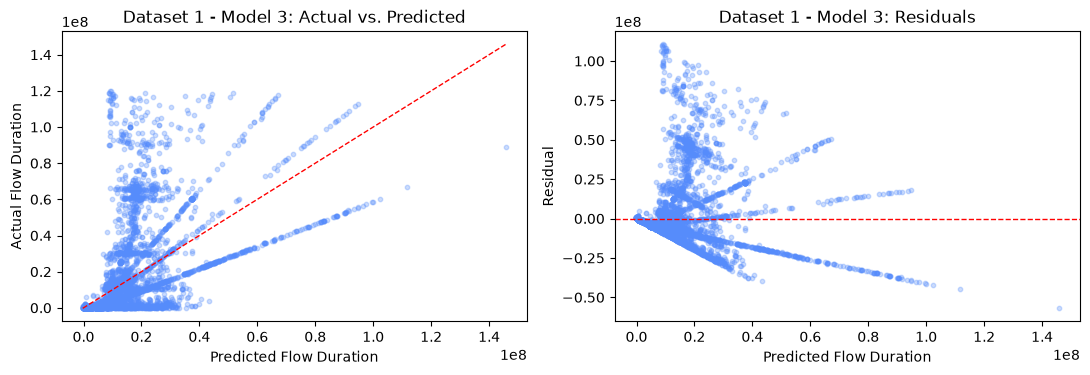

In [22]:
# Compare all three models, and inspect residuals for the final model
comparison = pd.DataFrame(results).set_index("model")
print(comparison)

y_pred_final = model_3.predict(X_test_pca)
residuals = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_pred_final, y_test, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Predicted Flow Duration")
axes[0].set_ylabel("Actual Flow Duration")
axes[0].set_title("Dataset 1 - Model 3: Actual vs. Predicted")

axes[1].scatter(y_pred_final, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted Flow Duration")
axes[1].set_ylabel("Residual")
axes[1].set_title("Dataset 1 - Model 3: Residuals")

plt.tight_layout()
plt.show()


**Dataset 1 takeaways (37,809-row cleaned dataset):** forward and backward selection land on very different subsets and very different scores (R^2 = 0.351 vs. 0.427), even though both are searching the same 8 features for the same target. Forward selection greedily adds Packet Length Mean and Flow IAT Mean first (the two weakest-VIF, most individually-informative features) and then fills its budget with the protocol dummies, never revisiting that early choice - so it never picks up Total Backward Packets or either Length feature at all. Backward selection starts from the full model and removes the least useful predictor at each step, which lets it keep Total Backward Packets and drop the weaker protocol dummies instead, landing on a noticeably better fit. This is a textbook illustration of why the two directions are not guaranteed to agree: greedy forward search can get locked into a path that looks good early but is jointly suboptimal, while backward search benefits from seeing the full feature set before deciding what to cut. Principal component regression (R^2 = 0.346, 5 of 8 components explaining 98% of the variance) performs about as well as forward selection here - PCA's components are chosen to explain variance in the predictors, not to predict Flow Duration, so a component that captures a lot of variance can still be weakly related to the target.

## Dataset 2: Intrusion

### Setup

In [23]:
# Load the dataset

# Load and combine the datasets
files = [
    "network_traffic_1.csv",
    "network_traffic_2.csv",
    "network_traffic_3.csv",
    "network_traffic_4.csv",
    "network_traffic_5.csv",
    "network_traffic_6.csv",
    "network_traffic_7.csv",
    "network_traffic_8.csv"
]

# First read in as string to accommodate special character in Label column
dfs = []
for f in files:
    df = pd.read_csv(f, encoding="latin1", dtype=str)
    df.columns = df.columns.str.strip()  # source CSVs have inconsistent leading spaces in headers
    dfs.append(df)

intrusion_df = pd.concat(dfs, ignore_index=True)

# Convert numeric columns to numbers
numeric_candidates = [c for c in intrusion_df.columns if c != 'Label']
intrusion_df[numeric_candidates] = intrusion_df[numeric_candidates].apply(pd.to_numeric, errors='coerce')

# Infinity parses to np.inf rather than NaN — if you want those treat as missing/dropped like NaN
intrusion_df[numeric_candidates] = intrusion_df[numeric_candidates].replace([np.inf, -np.inf], np.nan)

print(intrusion_df.shape)

(2830743, 79)


In [24]:
# Print the dataset
intrusion_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [25]:
# Normalize the Label column

# Where 0: 'BENIGN', 1: 'Bot', 2: 'DDoS', 3: 'DoS GoldenEye', 4: 'DoS Hulk', 5: 'DoS Slowhttptest',
# 6: 'DoS slowloris', 7: 'FTP-Patator', 8: 'Heartbleed', 9: 'Infiltration', 10: 'PortScan', 11: 'SSH-Patator',
# 12: 'Web Attack - Brute Force', 13: 'Web Attack - Sql Injection', 14: 'Web Attack - XSS'
intrusion_df["Label"] = (
    intrusion_df["Label"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(r"Web Attack.*Brute Force", "Web Attack - Brute Force", regex=True)
    .str.replace(r"Web Attack.*Sql Injection", "Web Attack - Sql Injection", regex=True)
    .str.replace(r"Web Attack.*XSS", "Web Attack - XSS", regex=True)
)

# Build mapping from all unique label strings to integers
classes = sorted(intrusion_df["Label"].unique())
label_to_int = {label: i for i, label in enumerate(classes)}

with np.printoptions(threshold=np.inf):
    print("Before:", intrusion_df["Label"].astype("string").unique())

    intrusion_df["Label"] = intrusion_df["Label"].map(label_to_int)

    print("After:", intrusion_df["Label"].unique())

print(intrusion_df["Label"].value_counts())

Before: <StringArray>
[                    'BENIGN',                       'DDoS',
                   'PortScan',                        'Bot',
               'Infiltration',   'Web Attack - Brute Force',
           'Web Attack - XSS', 'Web Attack - Sql Injection',
                'FTP-Patator',                'SSH-Patator',
              'DoS slowloris',           'DoS Slowhttptest',
                   'DoS Hulk',              'DoS GoldenEye',
                 'Heartbleed']
Length: 15, dtype: string
After: [ 0  2 10  1  9 12 14 13  7 11  6  5  4  3  8]
Label
0     2273097
4      231073
10     158930
2      128027
3       10293
7        7938
11       5897
6        5796
5        5499
1        1966
12       1507
14        652
9          36
13         21
8          11
Name: count, dtype: int64


In [26]:
# Drop duplicate rows
before = len(intrusion_df)
intrusion_df = intrusion_df.drop_duplicates()
print(f"Dropped {before - len(intrusion_df)} duplicate rows -> {len(intrusion_df)} rows remaining")

Dropped 308381 duplicate rows -> 2522362 rows remaining


In [27]:
# Drop null & NaN values
before = len(intrusion_df)
intrusion_df = intrusion_df.dropna()  # covers both nulls and NaNs
print(f"Dropped {before - len(intrusion_df)} rows with null/NaN values -> {len(intrusion_df)} rows remaining")

Dropped 1564 rows with null/NaN values -> 2520798 rows remaining


In [28]:
# Drop negative values
before = len(intrusion_df)
numeric_cols = intrusion_df.select_dtypes(include=[np.number]).columns

# Init_Win_bytes_forward / Init_Win_bytes_backward use -1 as a sentinel meaning
# "no forward/backward-direction window observed" (not invalid data), so they are
# excluded from the negative-value check — same fix already applied to ransomware.
negative_check_cols = numeric_cols.drop(['Init_Win_bytes_forward', 'Init_Win_bytes_backward'])

negative_mask = (intrusion_df[negative_check_cols] < 0).any(axis=1)
intrusion_df = intrusion_df[~negative_mask]
print(f"Dropped {before - len(intrusion_df)} rows containing negative values (excluding Init_Win_bytes_forward/backward) -> {len(intrusion_df)} rows remaining")

Dropped 2915 rows containing negative values (excluding Init_Win_bytes_forward/backward) -> 2517883 rows remaining


In [29]:
# Drop non-numeric columns
non_numeric_cols = intrusion_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

intrusion_df = intrusion_df.drop(columns=non_numeric_cols)
print(intrusion_df.shape)

Dropping non-numeric columns: []
(2517883, 79)


In [30]:
# Drop perfectly correlated columns
corr_matrix = intrusion_df.drop(columns=['Label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

intrusion_df = intrusion_df.drop(columns=perfectly_correlated)
print(intrusion_df.shape)

Dropping 9 columns with ~1.00 correlation to an earlier column:
['SYN Flag Count', 'CWE Flag Count', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes']
(2517883, 70)


In [31]:
# Drop duplicate rows (post feature engineering)
before = len(intrusion_df)
intrusion_df = intrusion_df.drop_duplicates()
print(f"Dropped {before - len(intrusion_df)} duplicate rows -> {len(intrusion_df)} rows remaining")

Dropped 0 duplicate rows -> 2517883 rows remaining


In [32]:
# Print cleaned DataFrame
intrusion_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,1,0,0,0,9.0,0,0,0,0,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,1,0,0,0,9.0,0,0,0,0,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0


In [33]:
# Sanity check
print("Any nulls left:", intrusion_df.isnull().values.any())
print("Any negatives left:", (intrusion_df < 0).values.any())
print("Any duplicate rows left:", intrusion_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in intrusion_df.dtypes))
print("\nFinal shape:", intrusion_df.shape)
print("\nLabel counts:")
print(intrusion_df['Label'].value_counts())

Any nulls left: False
Any negatives left: True
Any duplicate rows left: False
All columns numeric: True

Final shape: (2517883, 70)

Label counts:
Label
0     2092335
4      172688
2      127995
10      90694
3       10281
7        5927
6        5385
5        5228
11       3217
1        1948
12       1470
14        652
9          35
13         21
8           7
Name: count, dtype: int64


In [34]:
# Export cleaned data to CSV
intrusion_df.to_csv("intrusion_newtork_traffic_clean.csv", index=False)
print("Saved intrusion_newtork_traffic_clean.csv")

Saved intrusion_newtork_traffic_clean.csv


### Regression Analysis

Goal: model **Flow Duration** (microseconds) - a continuous outcome - as a function of
packet/byte-count features and the flow's **Protocol** (TCP vs. UDP vs. other), a
categorical feature. Parts 1 and 2 handled the multicollinearity among these features
with a VIF-driven manual drop and then with regularized regression, respectively. This
section takes a third approach - automatic **feature selection** (forward and backward
stepwise search) and **dimensionality reduction** (principal component regression) -
both applied to the same standardized design matrix.

Same target as the malware dataset - **Flow Duration** - so the two flow-based datasets can be compared directly. This dataset has no Protocol column, so the categorical feature here is a **destination-port tier** (well-known / registered / dynamic).


In [35]:
# Build the modeling frame: continuous predictors + a categorical Protocol feature
target_col = "Flow Duration"

continuous_candidates = [
    "Total Fwd Packets", "Total Backward Packets",
    "Total Length of Fwd Packets", "Total Length of Bwd Packets",
    "Packet Length Mean", "Flow IAT Mean",
]
continuous_cols = [c for c in continuous_candidates if c in intrusion_df.columns]

model_df = intrusion_df[[target_col] + continuous_cols].copy()

if "Protocol" in intrusion_df.columns:
    model_df["protocol_cat"] = to_protocol_category(intrusion_df["Protocol"])
else:
    model_df["protocol_cat"] = to_port_tier(intrusion_df["Destination Port"])

# Flow Duration of 0 means the flow was instantaneous / not meaningfully observed
model_df = model_df[model_df[target_col] > 0].dropna()

print("Continuous predictors:", continuous_cols)
print("Categorical predictor: protocol_cat ->", model_df["protocol_cat"].value_counts().to_dict())
print("Modeling frame shape:", model_df.shape)
model_df.head()


Continuous predictors: ['Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Packet Length Mean', 'Flow IAT Mean']
Categorical predictor: protocol_cat -> {'well_known': 1971689, 'dynamic': 302561, 'registered': 243633}
Modeling frame shape: (2517883, 8)


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Packet Length Mean,Flow IAT Mean,protocol_cat
0,3,2,0,12,0,6.0,3.0,dynamic
1,109,1,1,6,6,6.0,109.0,dynamic
2,52,1,1,6,6,6.0,52.0,dynamic
3,34,1,1,6,6,6.0,34.0,registered
4,3,2,0,12,0,6.0,3.0,dynamic


In [36]:
# One-hot encode the categorical feature, split into train/test, and scale
cat_dummies = pd.get_dummies(model_df["protocol_cat"], prefix="port_tier", drop_first=True)
X_all = pd.concat([model_df[continuous_cols], cat_dummies], axis=1).astype(float)
y_all = model_df[target_col].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
)

# Forward/backward selection compare models fit on different feature subsets, and PCR's
# components are only meaningful when every input is on the same scale - fit the scaler
# on the training data only, then apply it to both.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Design matrix columns:", X_all.columns.tolist())
print("Train/test sizes:", X_train.shape, X_test.shape)


Design matrix columns: ['Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Packet Length Mean', 'Flow IAT Mean', 'port_tier_registered', 'port_tier_well_known']
Train/test sizes: (2014306, 8) (503577, 8)


#### Model 1: Forward Selection

In [37]:
# Model 1: Forward Selection - greedy search that starts with no features and adds
# whichever remaining feature most improves 5-fold CV R^2 at each step, stopping once half
# of the candidate features have been selected.
results = []
sfs_fwd = SequentialFeatureSelector(LinearRegression(), n_features_to_select=0.5,
                                     direction="forward", scoring="r2", cv=5)
sfs_fwd.fit(X_train_scaled, y_train)
selected_fwd = X_train_scaled.columns[sfs_fwd.get_support()].tolist()
print("Forward-selected features:", selected_fwd)

model_1, r = fit_and_report(LinearRegression(), X_train_scaled[selected_fwd], y_train,
                             X_test_scaled[selected_fwd], y_test, "Model 1: Forward Selection")
results.append(r)


Forward-selected features: ['Packet Length Mean', 'Flow IAT Mean', 'port_tier_registered', 'port_tier_well_known']
Model 1: Forward Selection             R^2=  0.4002   RMSE= 27,317,893.00   MAE= 15,798,689.20


In [38]:
# Multicollinearity check: Variance Inflation Factor among the continuous predictors
vif_before = compute_vif(X_train[continuous_cols])
print("VIF - continuous predictors only:")
print(vif_before)

n_high = int((vif_before > 10).sum())
print(f"\n{n_high} of {len(vif_before)} continuous predictors exceed the VIF > 10 rule of thumb - "
      f"forward/backward selection below address this by choosing a feature subset, while "
      f"principal component regression sidesteps it entirely by regressing on orthogonal components.")


VIF - continuous predictors only:
Total Backward Packets         140.843121
Total Fwd Packets               98.155220
Total Length of Bwd Packets     82.229796
Total Length of Fwd Packets      1.638937
Packet Length Mean               1.054246
Flow IAT Mean                    1.032714
Name: VIF, dtype: float64

3 of 6 continuous predictors exceed the VIF > 10 rule of thumb - forward/backward selection below address this by choosing a feature subset, while principal component regression sidesteps it entirely by regressing on orthogonal components.


#### Model 2: Backward Selection

In [39]:
# Model 2: Backward Selection - the mirror image of Model 1: starts with every feature
# and removes whichever one hurts 5-fold CV R^2 the least at each step, stopping at the
# same target of half the candidate features.
sfs_bwd = SequentialFeatureSelector(LinearRegression(), n_features_to_select=0.5,
                                     direction="backward", scoring="r2", cv=5)
sfs_bwd.fit(X_train_scaled, y_train)
selected_bwd = X_train_scaled.columns[sfs_bwd.get_support()].tolist()
print("Backward-selected features:", selected_bwd)

model_2, r = fit_and_report(LinearRegression(), X_train_scaled[selected_bwd], y_train,
                             X_test_scaled[selected_bwd], y_test, "Model 2: Backward Selection")
results.append(r)


Backward-selected features: ['Total Fwd Packets', 'Total Length of Bwd Packets', 'Packet Length Mean', 'Flow IAT Mean']
Model 2: Backward Selection            R^2=  0.4149   RMSE= 26,980,896.73   MAE= 14,790,057.16


#### Model 3: Principal Component Regression

In [40]:
# Model 3: Principal Component Regression - PCA on the standardized design matrix,
# keeping enough orthogonal components to explain 95% of the variance, then an ordinary
# linear regression on those components. Because PCA components are uncorrelated by
# construction, this handles multicollinearity by construction rather than by selecting
# or dropping any of the original features.
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"PCA kept {pca.n_components_} of {X_train_scaled.shape[1]} original features as "
      f"components, explaining {pca.explained_variance_ratio_.sum():.1%} of the variance")

model_3, r = fit_and_report(LinearRegression(), X_train_pca, y_train, X_test_pca, y_test,
                             "Model 3: Principal Component Regression")
results.append(r)


PCA kept 5 of 8 original features as components, explaining 95.2% of the variance
Model 3: Principal Component Regression R^2=  0.4037   RMSE= 27,238,450.28   MAE= 15,762,821.03


### Comparison

                                               R2          RMSE           MAE
model                                                                        
Model 1: Forward Selection               0.400208  2.731789e+07  1.579869e+07
Model 2: Backward Selection              0.414915  2.698090e+07  1.479006e+07
Model 3: Principal Component Regression  0.403692  2.723845e+07  1.576282e+07


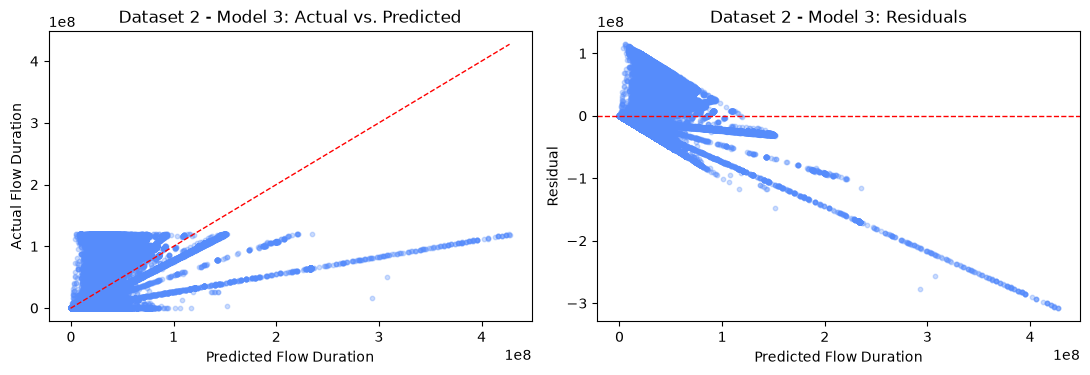

In [41]:
# Compare all three models, and inspect residuals for the final model
comparison = pd.DataFrame(results).set_index("model")
print(comparison)

y_pred_final = model_3.predict(X_test_pca)
residuals = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_pred_final, y_test, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Predicted Flow Duration")
axes[0].set_ylabel("Actual Flow Duration")
axes[0].set_title("Dataset 2 - Model 3: Actual vs. Predicted")

axes[1].scatter(y_pred_final, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted Flow Duration")
axes[1].set_ylabel("Residual")
axes[1].set_title("Dataset 2 - Model 3: Residuals")

plt.tight_layout()
plt.show()


**Dataset 2 takeaways:** this is the most collinear of the three datasets (Total Backward Packets VIF ~141, Total Fwd Packets ~98, Total Length of Bwd Packets ~82), and the same ranking from Dataset 1 shows up again - backward selection (R^2 = 0.415) beats principal component regression (0.404), which in turn edges out forward selection (0.400) - though the gaps are much tighter here than in Dataset 1. Backward selection keeps Total Fwd Packets and Total Length of Bwd Packets while dropping Total Backward Packets and one port-tier dummy; forward selection instead builds its subset around the two continuous features with the lowest VIF (Packet Length Mean, Flow IAT Mean) plus both port-tier dummies, missing the more informative but more collinear count/length features entirely. None of the three models comes close to Part 2's Elastic Net result on this dataset (R^2 = 0.617) - unsurprising, since this section never adds the polynomial/interaction terms that drove that jump, so the ceiling here is capped at roughly what a main-effects-only model can reach.

## Dataset 3: Misinformation

### Setup

In [42]:
# Load the dataset
misinformation_df = pd.read_csv("misinformation.csv", encoding="latin1", dtype=str)

# Drop unnamed index columns and clean up column names
misinformation_df = misinformation_df.loc[:, ~misinformation_df.columns.str.contains('^Unnamed')]
misinformation_df.columns = misinformation_df.columns.str.strip()

print(misinformation_df.shape)

(72134, 3)


In [43]:
# Print the dataset
misinformation_df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMAâS ATTORNEY GENERAL SAYS ...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [44]:
# Map the label column to numeric classes

# Where 1 = real, 0 = fake. Since they're already 0, 1, verify they are ints. 
print("Unique label values:", sorted(misinformation_df['label'].unique()))

misinformation_df['label'] = misinformation_df['label'].astype(int)
misinformation_df['label'].value_counts()

Unique label values: ['0', '1']


label
1    37106
0    35028
Name: count, dtype: int64

In [45]:
# Drop duplicate rows
before = len(misinformation_df)
misinformation_df = misinformation_df.drop_duplicates()
print(f"Dropped {before - len(misinformation_df)} duplicate rows -> {len(misinformation_df)} rows remaining")

Dropped 8456 duplicate rows -> 63678 rows remaining


In [46]:
# Drop null & NaN values
before = len(misinformation_df)
misinformation_df = misinformation_df.dropna()
print(f"Dropped {before - len(misinformation_df)} rows with null/NaN values -> {len(misinformation_df)} rows remaining")

Dropped 557 rows with null/NaN values -> 63121 rows remaining


In [47]:
# Create numeric columns
def add_text_features(df, col, prefix):
    text = df[col].astype(str)
    words = text.str.split()

    df[f'{prefix}_word_count'] = words.str.len()
    df[f'{prefix}_char_count'] = text.str.len()
    df[f'{prefix}_avg_word_length'] = (
        df[f'{prefix}_char_count'] / df[f'{prefix}_word_count'].replace(0, np.nan)
    ).fillna(0)
    df[f'{prefix}_exclamation_count'] = text.str.count('!')
    df[f'{prefix}_question_count'] = text.str.count(r'\?')
    df[f'{prefix}_digit_count'] = text.str.count(r'\d')
    df[f'{prefix}_uppercase_word_count'] = words.apply(
        lambda ws: sum(1 for w in ws if w.isupper() and len(w) > 1)
    )
    return df

misinformation_df = add_text_features(misinformation_df, 'title', 'title')
misinformation_df = add_text_features(misinformation_df, 'text', 'text')

misinformation_df.filter(like='_count').head()

,title_word_count,title_char_count,title_exclamation_count,title_question_count,title_digit_count,title_uppercase_word_count,text_word_count,text_char_count,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count
0,18,130,0,0,6,7,871,5049,2,7,30,6
2,18,145,1,0,0,9,34,216,0,0,0,0
3,16,105,0,0,4,0,1321,8120,0,1,34,7
4,16,101,0,0,1,1,329,1932,0,0,70,16
5,13,78,1,0,0,1,244,1530,1,0,0,13


In [48]:
# Drop negative values
before = len(misinformation_df)
numeric_cols = misinformation_df.select_dtypes(include=[np.number]).columns
negative_mask = (misinformation_df[numeric_cols] < 0).any(axis=1)
misinformation_df = misinformation_df[~negative_mask]
print(f"Dropped {before - len(misinformation_df)} rows containing negative values -> {len(misinformation_df)} rows remaining")

Dropped 0 rows containing negative values -> 63121 rows remaining


In [49]:
# Drop non-numeric columns
non_numeric_cols = misinformation_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

misinformation_df = misinformation_df.drop(columns=non_numeric_cols)
print(misinformation_df.shape)

Dropping non-numeric columns: ['title', 'text']
(63121, 15)


In [50]:
# Drop perfectly correlated columns
corr_matrix = misinformation_df.drop(columns=['label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

misinformation_df = misinformation_df.drop(columns=perfectly_correlated)
print(misinformation_df.shape)

Dropping 0 columns with ~1.00 correlation to an earlier column:
[]
(63121, 15)


In [51]:
# Drop duplicate rows (post feature engineering)
before = len(misinformation_df)
misinformation_df = misinformation_df.drop_duplicates()
print(f"Dropped {before - len(misinformation_df)} duplicate rows -> {len(misinformation_df)} rows remaining")

Dropped 48 duplicate rows -> 63073 rows remaining


In [52]:
# Print clean dataset
misinformation_df.head()

,label,title_word_count,title_char_count,title_avg_word_length,title_exclamation_count,title_question_count,title_digit_count,title_uppercase_word_count,text_word_count,text_char_count,text_avg_word_length,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count
0,1,18,130,7.222222,0,0,6,7,871,5049,5.796785,2,7,30,6
2,1,18,145,8.055556,1,0,0,9,34,216,6.352941,0,0,0,0
3,0,16,105,6.562500,0,0,4,0,1321,8120,6.146858,0,1,34,7
4,1,16,101,6.312500,0,0,1,1,329,1932,5.872340,0,0,70,16
5,1,13,78,6.000000,1,0,0,1,244,1530,6.270492,1,0,0,13


In [53]:
# Sanity check
print("Any nulls left:", misinformation_df.isnull().values.any())
print("Any negatives left:", (misinformation_df < 0).values.any())
print("Any duplicate rows left:", misinformation_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in misinformation_df.dtypes))
print("\nFinal shape:", misinformation_df.shape)
print("\nLabel counts:")
print(misinformation_df['label'].value_counts())

Any nulls left: False
Any negatives left: False
Any duplicate rows left: False
All columns numeric: True

Final shape: (63073, 15)

Label counts:
label
0    34780
1    28293
Name: count, dtype: int64


In [54]:
# Export cleaned data to CSV
misinformation_df.to_csv("misinformation_clean.csv", index=False)
print("Saved misinformation_clean.csv")

Saved misinformation_clean.csv


### Regression Analysis

Goal: model **title_char_count** (how long an article's headline is) from properties of
the article body - word count, punctuation usage, digit usage - plus the article's
**label** (real vs. fake) as a categorical feature. Parts 1 and 2 found little to no
multicollinearity among these text-based predictors, so this section is a useful
contrast case again: with few redundant features to select away or compress, forward
selection, backward selection, and principal component regression should all struggle
to improve much on simply keeping every feature.


In [55]:
# Build the modeling frame: continuous text-based predictors + a categorical label feature
target_col = "title_char_count"

continuous_candidates = [
    "text_word_count", "text_avg_word_length", "text_exclamation_count",
    "text_question_count", "text_digit_count", "text_uppercase_word_count",
]
continuous_cols = [c for c in continuous_candidates if c in misinformation_df.columns]

model_df = misinformation_df[[target_col] + continuous_cols + ["label"]].copy()
model_df["label_cat"] = model_df["label"].map({0: "fake", 1: "real"})
model_df = model_df[model_df[target_col] > 0].dropna()

print("Continuous predictors:", continuous_cols)
print("Categorical predictor: label_cat ->", model_df["label_cat"].value_counts().to_dict())
print("Modeling frame shape:", model_df.shape)
model_df.head()


Continuous predictors: ['text_word_count', 'text_avg_word_length', 'text_exclamation_count', 'text_question_count', 'text_digit_count', 'text_uppercase_word_count']
Categorical predictor: label_cat -> {'fake': 34780, 'real': 28293}
Modeling frame shape: (63073, 9)


,title_char_count,text_word_count,text_avg_word_length,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count,label,label_cat
0,130,871,5.796785,2,7,30,6,1,real
2,145,34,6.352941,0,0,0,0,1,real
3,105,1321,6.146858,0,1,34,7,0,fake
4,101,329,5.872340,0,0,70,16,1,real
5,78,244,6.270492,1,0,0,13,1,real


In [56]:
# One-hot encode the categorical feature, split into train/test, and scale
cat_dummies = pd.get_dummies(model_df["label_cat"], prefix="label", drop_first=True)
X_all = pd.concat([model_df[continuous_cols], cat_dummies], axis=1).astype(float)
y_all = model_df[target_col].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
)

# Forward/backward selection compare models fit on different feature subsets, and PCR's
# components are only meaningful when every input is on the same scale - fit the scaler
# on the training data only, then apply it to both.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Design matrix columns:", X_all.columns.tolist())
print("Train/test sizes:", X_train.shape, X_test.shape)


Design matrix columns: ['text_word_count', 'text_avg_word_length', 'text_exclamation_count', 'text_question_count', 'text_digit_count', 'text_uppercase_word_count', 'label_real']
Train/test sizes: (50458, 7) (12615, 7)


#### Model 1: Forward Selection

In [57]:
# Model 1: Forward Selection - greedy search that starts with no features and adds
# whichever remaining feature most improves 5-fold CV R^2 at each step, stopping once half
# of the candidate features have been selected.
results = []
sfs_fwd = SequentialFeatureSelector(LinearRegression(), n_features_to_select=0.5,
                                     direction="forward", scoring="r2", cv=5)
sfs_fwd.fit(X_train_scaled, y_train)
selected_fwd = X_train_scaled.columns[sfs_fwd.get_support()].tolist()
print("Forward-selected features:", selected_fwd)

model_1, r = fit_and_report(LinearRegression(), X_train_scaled[selected_fwd], y_train,
                             X_test_scaled[selected_fwd], y_test, "Model 1: Forward Selection")
results.append(r)


Forward-selected features: ['text_word_count', 'text_digit_count', 'label_real']
Model 1: Forward Selection             R^2=  0.1099   RMSE=         23.01   MAE=         15.86


In [58]:
# Multicollinearity check: Variance Inflation Factor among the continuous predictors
vif_before = compute_vif(X_train[continuous_cols])
print("VIF - continuous predictors only:")
print(vif_before)

n_high = int((vif_before > 10).sum())
print(f"\n{n_high} of {len(vif_before)} continuous predictors exceed the VIF > 10 rule of thumb - "
      f"forward/backward selection below address this by choosing a feature subset, while "
      f"principal component regression sidesteps it entirely by regressing on orthogonal components.")


VIF - continuous predictors only:
text_word_count              2.028195
text_question_count          1.876194
text_digit_count             1.519693
text_exclamation_count       1.447686
text_uppercase_word_count    1.103709
text_avg_word_length         1.017684
Name: VIF, dtype: float64

0 of 6 continuous predictors exceed the VIF > 10 rule of thumb - forward/backward selection below address this by choosing a feature subset, while principal component regression sidesteps it entirely by regressing on orthogonal components.


#### Model 2: Backward Selection

In [59]:
# Model 2: Backward Selection - the mirror image of Model 1: starts with every feature
# and removes whichever one hurts 5-fold CV R^2 the least at each step, stopping at the
# same target of half the candidate features.
sfs_bwd = SequentialFeatureSelector(LinearRegression(), n_features_to_select=0.5,
                                     direction="backward", scoring="r2", cv=5)
sfs_bwd.fit(X_train_scaled, y_train)
selected_bwd = X_train_scaled.columns[sfs_bwd.get_support()].tolist()
print("Backward-selected features:", selected_bwd)

model_2, r = fit_and_report(LinearRegression(), X_train_scaled[selected_bwd], y_train,
                             X_test_scaled[selected_bwd], y_test, "Model 2: Backward Selection")
results.append(r)


Backward-selected features: ['text_word_count', 'text_digit_count', 'label_real']
Model 2: Backward Selection            R^2=  0.1099   RMSE=         23.01   MAE=         15.86


#### Model 3: Principal Component Regression

In [60]:
# Model 3: Principal Component Regression - PCA on the standardized design matrix,
# keeping enough orthogonal components to explain 95% of the variance, then an ordinary
# linear regression on those components. Because PCA components are uncorrelated by
# construction, this handles multicollinearity by construction rather than by selecting
# or dropping any of the original features.
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"PCA kept {pca.n_components_} of {X_train_scaled.shape[1]} original features as "
      f"components, explaining {pca.explained_variance_ratio_.sum():.1%} of the variance")

model_3, r = fit_and_report(LinearRegression(), X_train_pca, y_train, X_test_pca, y_test,
                             "Model 3: Principal Component Regression")
results.append(r)


PCA kept 6 of 7 original features as components, explaining 95.7% of the variance
Model 3: Principal Component Regression R^2=  0.1105   RMSE=         23.01   MAE=         15.91


### Comparison

                                               R2       RMSE        MAE
model                                                                  
Model 1: Forward Selection               0.109882  23.013046  15.864900
Model 2: Backward Selection              0.109882  23.013046  15.864900
Model 3: Principal Component Regression  0.110496  23.005102  15.911289


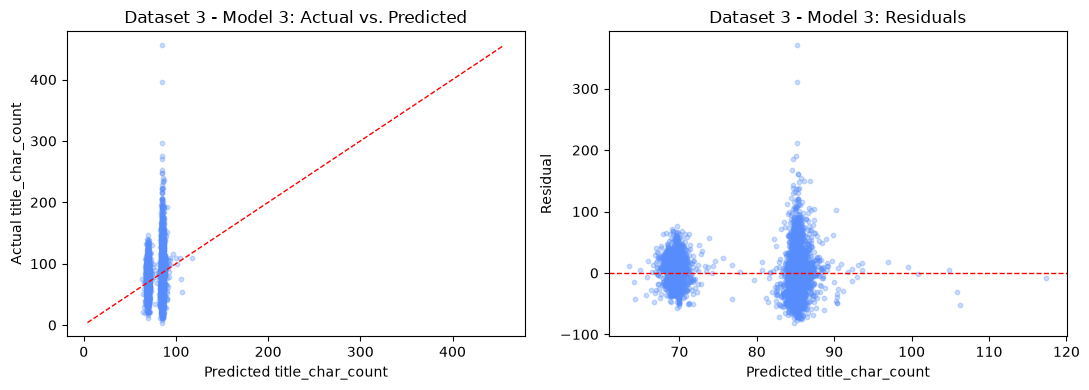

In [61]:
# Compare all three models, and inspect residuals for the final model
comparison = pd.DataFrame(results).set_index("model")
print(comparison)

y_pred_final = model_3.predict(X_test_pca)
residuals = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_pred_final, y_test, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Predicted title_char_count")
axes[0].set_ylabel("Actual title_char_count")
axes[0].set_title("Dataset 3 - Model 3: Actual vs. Predicted")

axes[1].scatter(y_pred_final, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted title_char_count")
axes[1].set_ylabel("Residual")
axes[1].set_title("Dataset 3 - Model 3: Residuals")

plt.tight_layout()
plt.show()


**Dataset 3 takeaways:** with essentially no multicollinearity among the text-based predictors (all VIFs under 2.1), forward and backward selection converge on the exact same three features (text_word_count, text_digit_count, label_real) and therefore the exact same score (R^2 = 0.1099) - when there is no redundancy to navigate around, the search direction stops mattering and both algorithms find the same locally-optimal subset. Principal component regression, which keeps 6 of the 7 standardized features as components (95.7% of the variance), lands within a hundredth of a point of the same result (0.1105). All three numbers are consistent with Parts 1 and 2's finding for this dataset: headline length is only weakly related to these body-text statistics, so no amount of feature selection or dimensionality reduction manufactures a stronger relationship than the data actually contains.

# Conclusion & Observations

Part 3 repeats the same three regression problems from Parts 1 and 2 - unchanged targets, predictors, and train/test splits - with a third approach to handling multicollinearity: automatic **feature selection** (forward and backward stepwise search over the standardized design matrix, scored by 5-fold CV R^2) and **dimensionality reduction** (principal component regression, keeping enough orthogonal components to explain 95% of the variance).

The clearest pattern across both flow-based datasets (1 and 2) is that backward selection consistently outperforms both forward selection and PCR (0.427 vs. 0.351 and 0.346 on Dataset 1; 0.415 vs. 0.400 and 0.404 on Dataset 2). That is a direct consequence of how the two search directions behave under multicollinearity: forward selection commits early to whichever single feature looks best in isolation and never revisits that choice, so on both datasets it ends up building its subset around the two least-collinear continuous features while missing the more collinear (but jointly more informative) packet/byte-count features entirely. Backward selection starts from the full model and removes the least useful predictor at each step, which lets it keep the informative-but-collinear features and instead drop weaker categorical dummies - a clear win when, as in these two datasets, the redundant features still carry real signal. Principal component regression sits in between: because its components are chosen to explain variance in the predictors rather than to predict the target, it performs respectably but without any mechanism to prioritize predictive power the way backward selection's CV-scored search does.

Dataset 3 tells the opposite story for a good reason: with essentially no multicollinearity among the text-based predictors, forward and backward selection converge on the identical three-feature subset and therefore the identical score (0.1099), and PCR lands within a hundredth of a point of the same result (0.1105) - when there is no redundancy to navigate, the choice of search direction (or of components over raw features) stops mattering.

It is also worth being explicit about what Part 3 does *not* do: unlike Part 2's Model 3 (Elastic Net plus polynomial and interaction terms, which reached R^2 = 0.657 and 0.617 on Datasets 1 and 2), none of this part's three models add any nonlinear structure - they only choose which linear features to keep or how to recombine them. That caps their ceiling well below Part 2's best results, even on Dataset 1 where backward selection's 0.427 comes reasonably close to Part 1's plain OLS baseline (0.454) without needing a human judgment call about which feature to drop. Taken together, the three parts of this assignment show multicollinearity being handled three different ways - by hand (VIF-driven dropping), automatically via shrinkage (regularization), and automatically via search or projection (selection and PCR) - but in every part, it is the presence or absence of the right nonlinear terms, not the multicollinearity-handling technique, that ultimately decides how high a model's R^2 can climb.